### Escalamiento, Normalización y Estandarización

### Introducción

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing

* Imaginemos que tenemos unas columnas que representan la información de varias personas.
* Hay registros que pueden representar sueldos, cantidad de autos, casas, hijos etc.
* Ahora imagemos que somos una técnica de aprendizaje sin tener el contexto, la técnica podría dar más prioridada los sueldos por que son los que cambian más, que por ejemplo la cantidad de carros.
* Las redes neuronales puden sesgadas por este estilo de situaciones.
* Para esto existen técnicas de homogeanización para controlar más estos sesgos.

In [3]:
datos = pd.read_csv('datos_personas.csv')
datos

,ingreso,carros
0,22273.577534,3
1,8961.047249,1
2,7437.977263,2
3,12064.915290,2
4,9296.396167,1
...,...,...
995,9998.522402,0
996,6867.097603,2
997,9757.539280,1
998,11044.031510,1


### Gráficando los datos en escala original

* `fig.add_subplot(1,3,1)`: la primera posición es un renglón y 3 columas, el ultimo hace referencia a la posición dentro del lienzo.
* En la primera imagen, hay tanta variación en los sueldos, que los gráfica de los carros casi no se nota. En este caso el plt se va con la impresión de los números más grandes.
* Realmente la tercera gráfica casi no nos ayuda a comprender lo de los carros.
* `linewidth`: grosor de la linea, si esta cero no habrá linea.

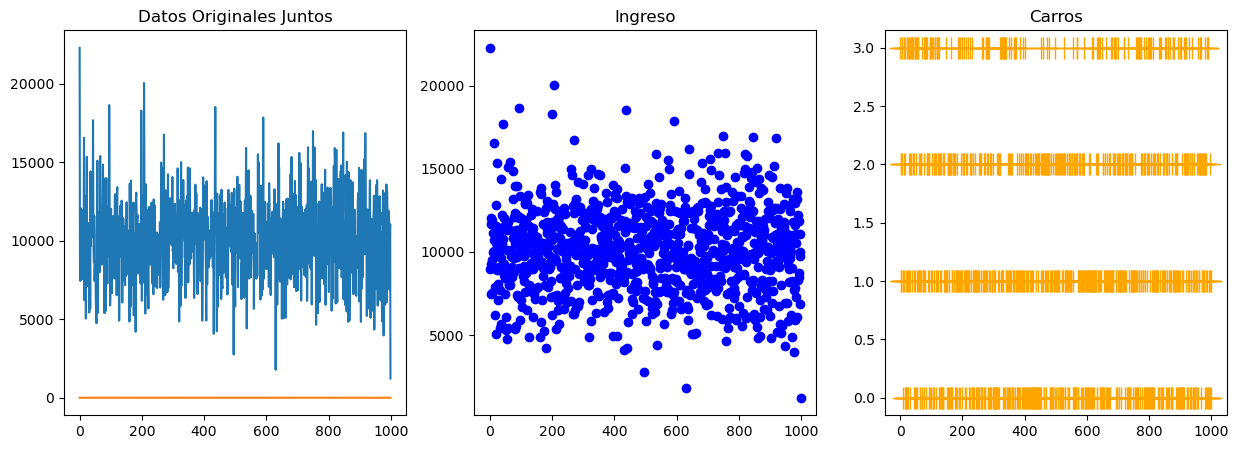

In [10]:
# Definimos el tamaño de nuestra figura
fig = plt.figure(figsize=(15,5))
# Establecemos que crearemos 3 subfiguras
ax1 = fig.add_subplot(1,3,1)
ax2 = fig.add_subplot(1,3,2)
ax3 = fig.add_subplot(1,3,3)

# Esto graficará sin contexto todos los datos
ax1.set_title("Datos Originales Juntos")
ax1.plot(datos)

# Esto simplemente gráfica los ingresos
ax2.set_title("Ingreso")
ax2.plot(datos["ingreso"], linewidth=0, marker="o", color="blue", markersize=6)

# Esto gráficara la tenencia de carros.
ax3.set_title("Carros")
ax3.plot(datos["carros"], linewidth=0, marker="+", color="orange", markersize=16)

plt.show()

### Distribución de los datos originales

* El figura, parte el lienzo, como los rows en bootstrap.
* Con los histogramas, podemos ver que el sueldo sigue una normal, por su lado la de carros sigue una distribución fisher.

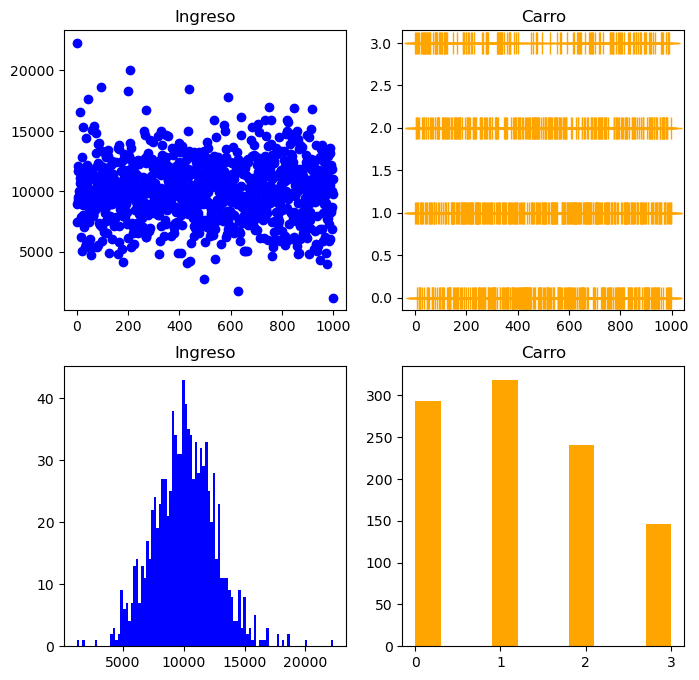

In [11]:
# 6 filas por 8 columnas el lienzo
fig = plt.figure(figsize=(8,8))

# metemos 4 grafos de 2 de altura y 2 de ancho.
ax1 = fig.add_subplot(2,2,1)
ax2 = fig.add_subplot(2,2,2)
ax3 = fig.add_subplot(2,2,3)
ax4 = fig.add_subplot(2,2,4)

# Graficamos los datos
ax1.set_title("Ingreso")
ax1.plot(datos["ingreso"], linewidth=0, marker="o", color="blue", markersize=6)

ax2.set_title("Carro")
ax2.plot(datos["carros"], linewidth=0, marker="+", color="orange", markersize=16)

# Veamos la distribución que sigue.
ax3.set_title("Ingreso")
ax3.hist(datos["ingreso"], bins=100, color="blue")

ax4.set_title("Carro")
ax4.hist(datos["carros"], color="orange")

plt.show()

### Escala en función del mínimo y máximo

* Esto lo que hará es transformar los valores en un rango de 0 a 1.
* Esto puede ayudar a optimizar algunos puntos.
* Para la primera columnas "sueldos", el valor más alto será 1 y el más bajo 0, para la cantidad de carros igual.

In [33]:
datos_min_max = preprocessing.MinMaxScaler().fit_transform(datos)
datos_min_max

array([[1.        , 1.        ],
       [0.36761553, 0.33333333],
       [0.29526521, 0.66666667],
       ...,
       [0.40545125, 0.33333333],
       [0.46656343, 0.33333333],
       [0.        , 0.        ]])

### Normaliza en función de la Norma del Vector

* Normalización no tiene nada que ver con la función normal.
* Este es un concepto de Álgebra Lineal.
* Esto calcula la normal del vector.
* Esto trabaja con filas no con columnas, por lo que se hizo la transpuesta.

In [34]:
datos_normalizer = preprocessing.Normalizer().fit_transform(datos.T)
datos_normalizer = datos_normalizer.T
datos_normalizer

array([[0.06777903, 0.05886881],
       [0.02726868, 0.01962294],
       [0.02263394, 0.03924588],
       ...,
       [0.02969242, 0.01962294],
       [0.03360725, 0.01962294],
       [0.00371935, 0.        ]])

### Estandariza (desv_std=1, media=0)

* Se trabaja con 1 y 0, ya que muchas tecnicas de aprendizaje esperan que sigan una distribución normal.
* El robusto usa el rango intercuartilico, el espacio de en medio Q3-Q1, principalmente por los datos atipicos.
* El robusto es el más utilzado

In [35]:
datos_standar_scaler = preprocessing.StandardScaler().fit_transform(datos)
datos_robust_scaler = preprocessing.RobustScaler().fit_transform(datos)

datos_standar_scaler, datos_robust_scaler

(array([[ 4.81555174,  1.70892042],
        [-0.4413019 , -0.23193185],
        [-1.04273197,  0.73849429],
        ...,
        [-0.12678303, -0.23193185],
        [ 0.38122719, -0.23193185],
        [-3.49719763, -1.20235798]]),
 array([[ 3.70548334,  1.        ],
        [-0.3376601 ,  0.        ],
        [-0.80023109,  0.5       ],
        ...,
        [-0.09575781,  0.        ],
        [ 0.29496225,  0.        ],
        [-2.68800607, -0.5       ]]))

### Columna 'ingreso': Comparación de métodos

* El Min-Max es el que más se ve afectada por los outliers.

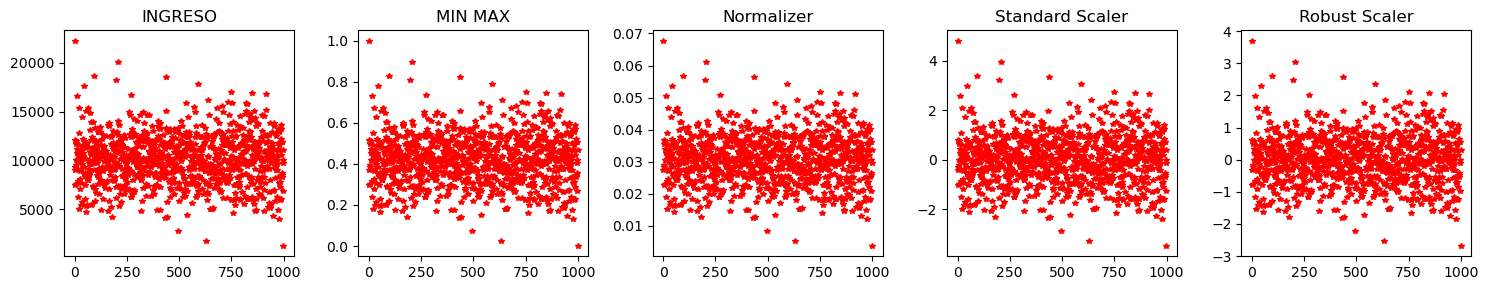

In [38]:
# convierte vectores de Numpy a DataFrames para graficarlos.
columnas = ["ingreso", "carros"]

# Escaladores
datos_min_max = pd.DataFrame(datos_min_max, columns=["ingreso","carros"])
datos_normalizer = pd.DataFrame(datos_normalizer, columns=["ingreso","carros"])
datos_standar_scaler = pd.DataFrame(datos_standar_scaler, columns=["ingreso","carros"])
datos_robust_scaler = pd.DataFrame(datos_robust_scaler, columns=["ingreso","carros"])

# crea una figura con 5 figuras para comparar los métodos
fig = plt.figure(figsize=(15,3))
ax1 = fig.add_subplot(1,5,1)
ax2 = fig.add_subplot(1,5,2)
ax3 = fig.add_subplot(1,5,3)
ax4 = fig.add_subplot(1,5,4)
ax5 = fig.add_subplot(1,5,5)

# crea y personaliza series de datos
ax1.set_title("INGRESO")
ax1.plot(datos["ingreso"], linewidth=0, marker="*", color="red", markersize=4)

ax2.set_title("MIN MAX")
ax2.plot(datos_min_max["ingreso"], linewidth=0, marker="*", color="red", markersize=4)

ax3.set_title("Normalizer")
ax3.plot(datos_normalizer["ingreso"], linewidth=0, marker="*", color="red", markersize=4)

ax4.set_title("Standard Scaler")
ax4.plot(datos_standard_scaler["ingreso"], linewidth=0, marker="*", color="red", markersize=4)

ax5.set_title("Robust Scaler")
ax5.plot(datos_robust_scaler["ingreso"], linewidth=0, marker="*", color="red", markersize=4)

plt.tight_layout()
plt.show()

### Histogramas

* Lo que cambia son los indices.

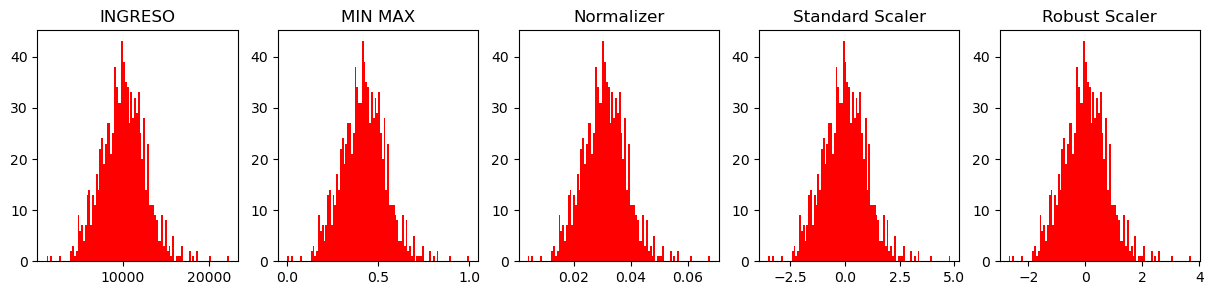

In [37]:
# crea una figura con 5 figuras para comparar los métodos
fig = plt.figure(figsize=(15,3))
ax1 = fig.add_subplot(1,5,1)
ax2 = fig.add_subplot(1,5,2)
ax3 = fig.add_subplot(1,5,3)
ax4 = fig.add_subplot(1,5,4)
ax5 = fig.add_subplot(1,5,5)

# crea y personaliza series de datos
ax1.set_title("INGRESO")
ax1.hist(datos["ingreso"], bins=100, color="red")

ax2.set_title("MIN MAX")
ax2.hist(datos_min_max["ingreso"], bins=100, color="red")

ax3.set_title("Normalizer")
ax3.hist(datos_normalizer["ingreso"], bins=100, color="red")

ax4.set_title("Standard Scaler")
ax4.hist(datos_standard_scaler["ingreso"], bins=100, color="red")

ax5.set_title("Robust Scaler")
ax5.hist(datos_robust_scaler["ingreso"], bins=100, color="red")

plt.show()

### Graficos en Carros.

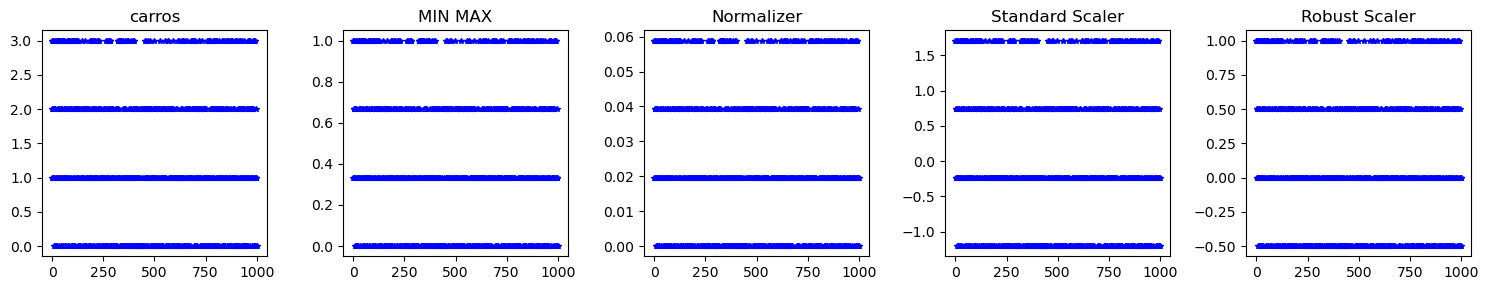

In [39]:
# crea una figura con 5 figuras para comparar los métodos
fig = plt.figure(figsize=(15,3))
ax1 = fig.add_subplot(1,5,1)
ax2 = fig.add_subplot(1,5,2)
ax3 = fig.add_subplot(1,5,3)
ax4 = fig.add_subplot(1,5,4)
ax5 = fig.add_subplot(1,5,5)

# crea y personaliza series de datos
ax1.set_title("carros")
ax1.plot(datos["carros"], linewidth=0, marker="*", color="blue", markersize=4)

ax2.set_title("MIN MAX")
ax2.plot(datos_min_max["carros"], linewidth=0, marker="*", color="blue", markersize=4)

ax3.set_title("Normalizer")
ax3.plot(datos_normalizer["carros"], linewidth=0, marker="*", color="blue", markersize=4)

ax4.set_title("Standard Scaler")
ax4.plot(datos_standard_scaler["carros"], linewidth=0, marker="*", color="blue", markersize=4)

ax5.set_title("Robust Scaler")
ax5.plot(datos_robust_scaler["carros"], linewidth=0, marker="*", color="blue", markersize=4)

plt.tight_layout()
plt.show()

### Histograma Carros

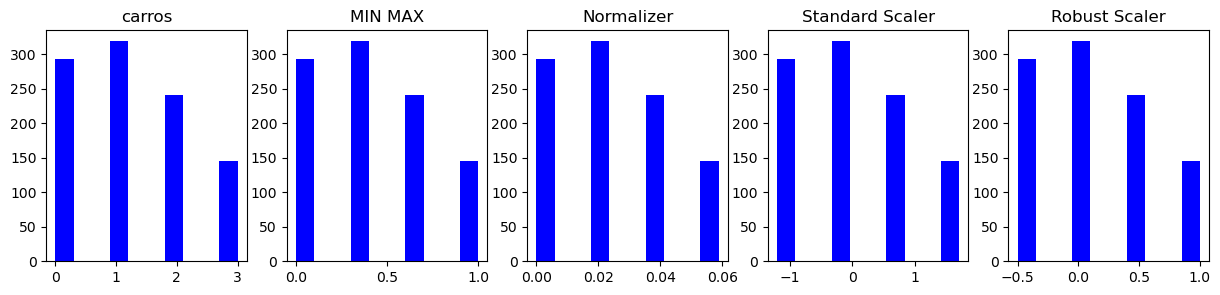

In [41]:
# crea una figura con 5 figuras para comparar los métodos
fig = plt.figure(figsize=(15,3))
ax1 = fig.add_subplot(1,5,1)
ax2 = fig.add_subplot(1,5,2)
ax3 = fig.add_subplot(1,5,3)
ax4 = fig.add_subplot(1,5,4)
ax5 = fig.add_subplot(1,5,5)

# crea y personaliza series de datos
ax1.set_title("carros")
ax1.hist(datos["carros"], color="blue")

ax2.set_title("MIN MAX")
ax2.hist(datos_min_max["carros"], color="blue")

ax3.set_title("Normalizer")
ax3.hist(datos_normalizer["carros"], color="blue")

ax4.set_title("Standard Scaler")
ax4.hist(datos_standard_scaler["carros"], color="blue")

ax5.set_title("Robust Scaler")
ax5.hist(datos_robust_scaler["carros"], color="blue")

plt.show()